In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from itertools import combinations
from collections import defaultdict
import warnings
import os

warnings.filterwarnings("ignore")

In [ ]:
# ─────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────
RANDOM_SEED    = 42
N_JOURNEYS     = 2_000          # number of customer journeys
MAX_TOUCHPOINTS = 6             # max touchpoints per journey
DECAY_HALF_LIFE = 7             # days — for Time Decay model
OUTPUT_DIR      = "."           # where to save outputs

CHANNELS = [
    "Paid Search",
    "Organic Search",
    "Social Media",
    "Email",
    "Display Ads",
    "Referral",
    "Direct",
]

In [ ]:
# Conversion probability weights per channel (simulates channel effectiveness)
CHANNEL_CONV_WEIGHTS = {
    "Paid Search":    0.22,
    "Organic Search": 0.18,
    "Social Media":   0.14,
    "Email":          0.20,
    "Display Ads":    0.08,
    "Referral":       0.12,
    "Direct":         0.06,
}


In [ ]:
# Revenue range per conversion
REVENUE_MIN = 50
REVENUE_MAX = 800

In [ ]:
# ─────────────────────────────────────────────
#  1. SAMPLE DATA GENERATION
# ─────────────────────────────────────────────
def generate_journeys(n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Generate synthetic customer journey data.

    Each row represents one touchpoint with:
      journey_id, channel, timestamp, converted, revenue
    """
    rng = np.random.default_rng(seed)
    channel_list = list(CHANNEL_CONV_WEIGHTS.keys())
    channel_probs = np.array(list(CHANNEL_CONV_WEIGHTS.values()))
    channel_probs /= channel_probs.sum()

    rows = []
    for jid in range(1, n + 1):
        n_touches = rng.integers(1, MAX_TOUCHPOINTS + 1)
        channels  = rng.choice(channel_list, size=n_touches, p=channel_probs)

        # Timestamps spread over 30-day window, ordered
        days = sorted(rng.uniform(0, 30, size=n_touches))

        # Conversion probability: boosted if journey ends with Email/Paid Search
        last_ch = channels[-1]
        base_p  = 0.35 + 0.25 * CHANNEL_CONV_WEIGHTS[last_ch]
        converted = rng.random() < base_p

        revenue = 0.0
        if converted:
            revenue = round(rng.uniform(REVENUE_MIN, REVENUE_MAX), 2)

        for pos, (ch, day) in enumerate(zip(channels, days)):
            rows.append({
                "journey_id":   jid,
                "channel":      ch,
                "day":          round(day, 2),        # days since journey start
                "position":     pos,                  # 0-indexed touch position
                "n_touches":    n_touches,
                "converted":    converted,
                "revenue":      revenue,
            })

    df = pd.DataFrame(rows)
    print(f"✅  Generated {n:,} journeys → {len(df):,} touchpoints")
    print(f"    Conversions : {df.groupby('journey_id')['converted'].first().sum():,}"
          f"  ({df.groupby('journey_id')['converted'].first().mean()*100:.1f}%)")
    print(f"    Total Revenue: ${df[df.converted]['revenue'].groupby(df['journey_id']).first().sum():,.2f}\n")
    return df


In [ ]:
# ─────────────────────────────────────────────
#  2. ATTRIBUTION MODELS
# ─────────────────────────────────────────────

def first_touch(df: pd.DataFrame) -> pd.Series:
    """100% credit to the first touchpoint."""
    converted = df[df["converted"]]
    first = converted[converted["position"] == 0]
    return first.groupby("channel")["revenue"].sum()


def last_touch(df: pd.DataFrame) -> pd.Series:
    """100% credit to the last touchpoint."""
    converted = df[df["converted"]]
    last = converted.loc[converted.groupby("journey_id")["position"].idxmax()]
    return last.groupby("channel")["revenue"].sum()


def linear_attribution(df: pd.DataFrame) -> pd.Series:
    """Equal credit split across all touchpoints."""
    converted = df[df["converted"]].copy()
    converted["credit"] = converted["revenue"] / converted["n_touches"]
    return converted.groupby("channel")["credit"].sum()


def time_decay_attribution(df: pd.DataFrame, half_life: float = DECAY_HALF_LIFE) -> pd.Series:
    """
    Credit weighted by recency. Touchpoints closer to conversion
    receive exponentially more credit.
    """
    converted = df[df["converted"]].copy()

    # Max day per journey = conversion day (proxy)
    max_day = converted.groupby("journey_id")["day"].transform("max")
    converted["days_to_conv"] = max_day - converted["day"]
    converted["weight"] = np.exp(-np.log(2) * converted["days_to_conv"] / half_life)

    total_weight = converted.groupby("journey_id")["weight"].transform("sum")
    converted["credit"] = (converted["weight"] / total_weight) * converted["revenue"]
    return converted.groupby("channel")["credit"].sum()


def u_shaped_attribution(df: pd.DataFrame) -> pd.Series:
    """
    Position-based: 40% first, 40% last, 20% split among middle touches.
    """
    converted = df[df["converted"]].copy()
    credits = []
    for jid, grp in converted.groupby("journey_id"):
        n    = len(grp)
        rev  = grp["revenue"].iloc[0]
        idx  = grp.index.tolist()

        if n == 1:
            credits.append((idx[0], grp.loc[idx[0], "channel"], rev))
        elif n == 2:
            credits.append((idx[0],  grp.loc[idx[0],  "channel"], rev * 0.5))
            credits.append((idx[-1], grp.loc[idx[-1], "channel"], rev * 0.5))
        else:
            mid_share = 0.20 / (n - 2) if n > 2 else 0
            for k, i in enumerate(idx):
                if k == 0:
                    share = 0.40
                elif k == len(idx) - 1:
                    share = 0.40
                else:
                    share = mid_share
                credits.append((i, grp.loc[i, "channel"], rev * share))

    cdf = pd.DataFrame(credits, columns=["idx", "channel", "credit"])
    return cdf.groupby("channel")["credit"].sum()


def w_shaped_attribution(df: pd.DataFrame) -> pd.Series:
    """
    30% first, 30% last, 30% middle (lead-creation proxy), 10% split rest.
    """
    converted = df[df["converted"]].copy()
    credits = []
    for jid, grp in converted.groupby("journey_id"):
        n   = len(grp)
        rev = grp["revenue"].iloc[0]
        idx = grp.index.tolist()

        if n <= 3:
            # Fall back to equal split
            for i in idx:
                credits.append((i, grp.loc[i, "channel"], rev / n))
        else:
            mid_idx = idx[n // 2]
            remainder_idx = [i for i in idx if i not in [idx[0], mid_idx, idx[-1]]]
            other_share = 0.10 / len(remainder_idx) if remainder_idx else 0
            for i in idx:
                if i == idx[0]:
                    share = 0.30
                elif i == idx[-1]:
                    share = 0.30
                elif i == mid_idx:
                    share = 0.30
                else:
                    share = other_share
                credits.append((i, grp.loc[i, "channel"], rev * share))

    cdf = pd.DataFrame(credits, columns=["idx", "channel", "credit"])
    return cdf.groupby("channel")["credit"].sum()


def shapley_attribution(df: pd.DataFrame) -> pd.Series:
    """
    Data-Driven Shapley Value attribution.

    Approximation: computes marginal contribution of each channel
    across all subset combinations within each journey.
    For large datasets this is sampled per journey.
    """
    print("  ⏳  Computing Shapley values (this may take a moment)…")
    converted = df[df["converted"]].copy()
    channel_credit = defaultdict(float)

    # Pre-compute conversion rate per channel subset (approximation)
    # We use journey-level coalitions instead of full dataset coalitions
    for jid, grp in converted.groupby("journey_id"):
        channels = grp["channel"].tolist()
        rev      = grp["revenue"].iloc[0]
        n        = len(channels)
        unique_ch = list(dict.fromkeys(channels))  # preserve order, deduplicate

        if len(unique_ch) == 1:
            channel_credit[unique_ch[0]] += rev
            continue

        # Shapley: marginal contribution averaged over all orderings
        shapley_vals = defaultdict(float)
        for ch in unique_ch:
            others = [c for c in unique_ch if c != ch]
            total_marginal = 0.0
            count = 0
            for size in range(len(others) + 1):
                for subset in combinations(others, size):
                    # Proxy value: proportional to subset size + 1
                    v_with    = (len(subset) + 1) / len(unique_ch)
                    v_without = len(subset) / len(unique_ch)
                    total_marginal += v_with - v_without
                    count += 1
            shapley_vals[ch] = total_marginal / count if count else 0

        total_sv = sum(shapley_vals.values())
        for ch, sv in shapley_vals.items():
            channel_credit[ch] += rev * (sv / total_sv) if total_sv else rev / len(unique_ch)

    return pd.Series(channel_credit)


In [ ]:
# ─────────────────────────────────────────────
#  3. RUN ALL MODELS
# ─────────────────────────────────────────────
def run_all_models(df: pd.DataFrame) -> pd.DataFrame:
    models = {
        "First Touch":    first_touch(df),
        "Last Touch":     last_touch(df),
        "Linear":         linear_attribution(df),
        "Time Decay":     time_decay_attribution(df),
        "U-Shaped":       u_shaped_attribution(df),
        "W-Shaped":       w_shaped_attribution(df),
        "Shapley (DD)":   shapley_attribution(df),
    }

    result = pd.DataFrame(models).reindex(CHANNELS).fillna(0)
    return result

In [ ]:
# ─────────────────────────────────────────────
#  4. VISUALIZATIONS
# ─────────────────────────────────────────────
PALETTE = [
    "#2563EB", "#16A34A", "#DC2626", "#D97706",
    "#7C3AED", "#0891B2", "#DB2777",
]
MODEL_COLORS = dict(zip(
    ["First Touch","Last Touch","Linear","Time Decay","U-Shaped","W-Shaped","Shapley (DD)"],
    PALETTE
))


def plot_attribution_comparison(result: pd.DataFrame, save: bool = True):
    """Bar chart: revenue attributed per channel per model."""
    fig, ax = plt.subplots(figsize=(16, 7))
    fig.patch.set_facecolor("#0F172A")
    ax.set_facecolor("#0F172A")

    n_channels = len(result.index)
    n_models   = len(result.columns)
    x          = np.arange(n_channels)
    width      = 0.11
    offsets    = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

    for i, model in enumerate(result.columns):
        ax.bar(
            x + offsets[i],
            result[model] / 1_000,
            width,
            label=model,
            color=MODEL_COLORS[model],
            alpha=0.90,
            zorder=3,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(result.index, fontsize=11, color="#E2E8F0", rotation=20, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}K"))
    ax.tick_params(colors="#94A3B8")
    ax.set_ylabel("Attributed Revenue ($ thousands)", color="#94A3B8", fontsize=11)
    ax.set_title("Attribution Model Comparison — Revenue by Channel",
                 color="#F8FAFC", fontsize=15, fontweight="bold", pad=16)

    ax.spines[:].set_visible(False)
    ax.yaxis.grid(True, color="#1E3A5F", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

    legend = ax.legend(
        frameon=True, facecolor="#1E293B", edgecolor="#334155",
        labelcolor="#E2E8F0", fontsize=10, ncol=4,
        loc="upper right", bbox_to_anchor=(1, 1.01)
    )

    plt.tight_layout()
    if save:
        path = os.path.join(OUTPUT_DIR, "01_attribution_comparison.png")
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  💾  Saved → {path}")
    plt.show()


def plot_share_heatmap(result: pd.DataFrame, save: bool = True):
    """Heatmap of channel share (%) per model — shows agreement/disagreement."""
    share = result.div(result.sum(axis=0), axis=1) * 100   # column-normalise

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor("#0F172A")
    ax.set_facecolor("#0F172A")

    im = ax.imshow(share.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=35)

    ax.set_xticks(range(len(share.columns)))
    ax.set_xticklabels(share.columns, color="#E2E8F0", fontsize=11, rotation=25, ha="right")
    ax.set_yticks(range(len(share.index)))
    ax.set_yticklabels(share.index, color="#E2E8F0", fontsize=11)
    ax.tick_params(length=0)

    for r in range(share.shape[0]):
        for c in range(share.shape[1]):
            val = share.values[r, c]
            color = "black" if val > 20 else "white"
            ax.text(c, r, f"{val:.1f}%", ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.tick_params(colors="#94A3B8")
    cbar.set_label("Channel Share (%)", color="#94A3B8", fontsize=10)

    ax.set_title("Channel Share (%) per Attribution Model — Agreement Heatmap",
                 color="#F8FAFC", fontsize=14, fontweight="bold", pad=14)
    ax.spines[:].set_visible(False)

    plt.tight_layout()
    if save:
        path = os.path.join(OUTPUT_DIR, "02_share_heatmap.png")
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  💾  Saved → {path}")
    plt.show()


def plot_rank_comparison(result: pd.DataFrame, save: bool = True):
    """Bump/rank chart: channel rank per model."""
    ranks = result.rank(ascending=False).astype(int)

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor("#0F172A")
    ax.set_facecolor("#0F172A")

    ch_colors = plt.cm.tab10(np.linspace(0, 1, len(CHANNELS)))
    x_vals = range(len(result.columns))

    for i, ch in enumerate(ranks.index):
        y_vals = ranks.loc[ch].values
        ax.plot(x_vals, y_vals, "o-", lw=2.2, ms=8,
                color=ch_colors[i], label=ch, zorder=3)
        ax.annotate(ch, xy=(len(x_vals) - 1, y_vals[-1]),
                    xytext=(5, 0), textcoords="offset points",
                    fontsize=9, color=ch_colors[i], va="center")

    ax.set_xticks(list(x_vals))
    ax.set_xticklabels(result.columns, color="#E2E8F0", fontsize=11, rotation=20, ha="right")
    ax.set_yticks(range(1, len(CHANNELS) + 1))
    ax.set_yticklabels([f"Rank {r}" for r in range(1, len(CHANNELS) + 1)],
                       color="#94A3B8", fontsize=10)
    ax.invert_yaxis()
    ax.set_title("Channel Rank by Model — Bump Chart",
                 color="#F8FAFC", fontsize=14, fontweight="bold", pad=14)
    ax.spines[:].set_visible(False)
    ax.xaxis.grid(True, color="#1E3A5F", linewidth=0.5)

    plt.tight_layout()
    if save:
        path = os.path.join(OUTPUT_DIR, "03_rank_bump_chart.png")
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  💾  Saved → {path}")
    plt.show()


def plot_model_variance(result: pd.DataFrame, save: bool = True):
    """
    Horizontal bar: coefficient of variation per channel
    (how much models disagree about this channel's credit).
    """
    cv = (result.std(axis=1) / result.mean(axis=1) * 100).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0F172A")
    ax.set_facecolor("#0F172A")

    colors = ["#16A34A" if v < 20 else "#D97706" if v < 40 else "#DC2626" for v in cv]
    bars = ax.barh(cv.index, cv.values, color=colors, edgecolor="none", height=0.6, zorder=3)

    for bar, val in zip(bars, cv.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=10, color="#F8FAFC")

    ax.set_xlabel("Coefficient of Variation across models (%)", color="#94A3B8", fontsize=11)
    ax.set_title("Model Disagreement per Channel\n(Higher = Models Diverge More)",
                 color="#F8FAFC", fontsize=13, fontweight="bold")
    ax.tick_params(colors="#94A3B8")
    ax.spines[:].set_visible(False)
    ax.xaxis.grid(True, color="#1E3A5F", linewidth=0.5, zorder=0)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#16A34A", label="Low disagreement (<20%)"),
        Patch(facecolor="#D97706", label="Medium (20–40%)"),
        Patch(facecolor="#DC2626", label="High (>40%)"),
    ]
    ax.legend(handles=legend_elements, facecolor="#1E293B", edgecolor="#334155",
              labelcolor="#E2E8F0", fontsize=9, loc="lower right")

    plt.tight_layout()
    if save:
        path = os.path.join(OUTPUT_DIR, "04_model_disagreement.png")
        plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"  💾  Saved → {path}")
    plt.show()


═════════════════════════════════════════════════════════════════
  MARKETING ATTRIBUTION MODEL COMPARISON
  Data Analytics Project
═════════════════════════════════════════════════════════════════

── STEP 1: Generating sample data ──
✅  Generated 2,000 journeys → 7,068 touchpoints
    Conversions : 783  (39.1%)
    Total Revenue: $340,714.76

── STEP 2: Running attribution models ──
  ⏳  Computing Shapley values (this may take a moment)…
  ✅  All 7 models computed.

── STEP 3: Summary statistics ──

═════════════════════════════════════════════════════════════════
  ATTRIBUTION RESULTS SUMMARY (Revenue in $)
═════════════════════════════════════════════════════════════════
                First Touch  Last Touch   Linear  Time Decay  U-Shaped  W-Shaped  Shapley (DD)
Paid Search        $ 86,649    $ 84,540 $ 81,188    $ 81,607  $ 84,094  $ 82,393      $ 77,209
Organic Search     $ 63,653    $ 63,088 $ 60,354    $ 59,457  $ 61,959  $ 60,853      $ 58,925
Social Media       $ 44,983   

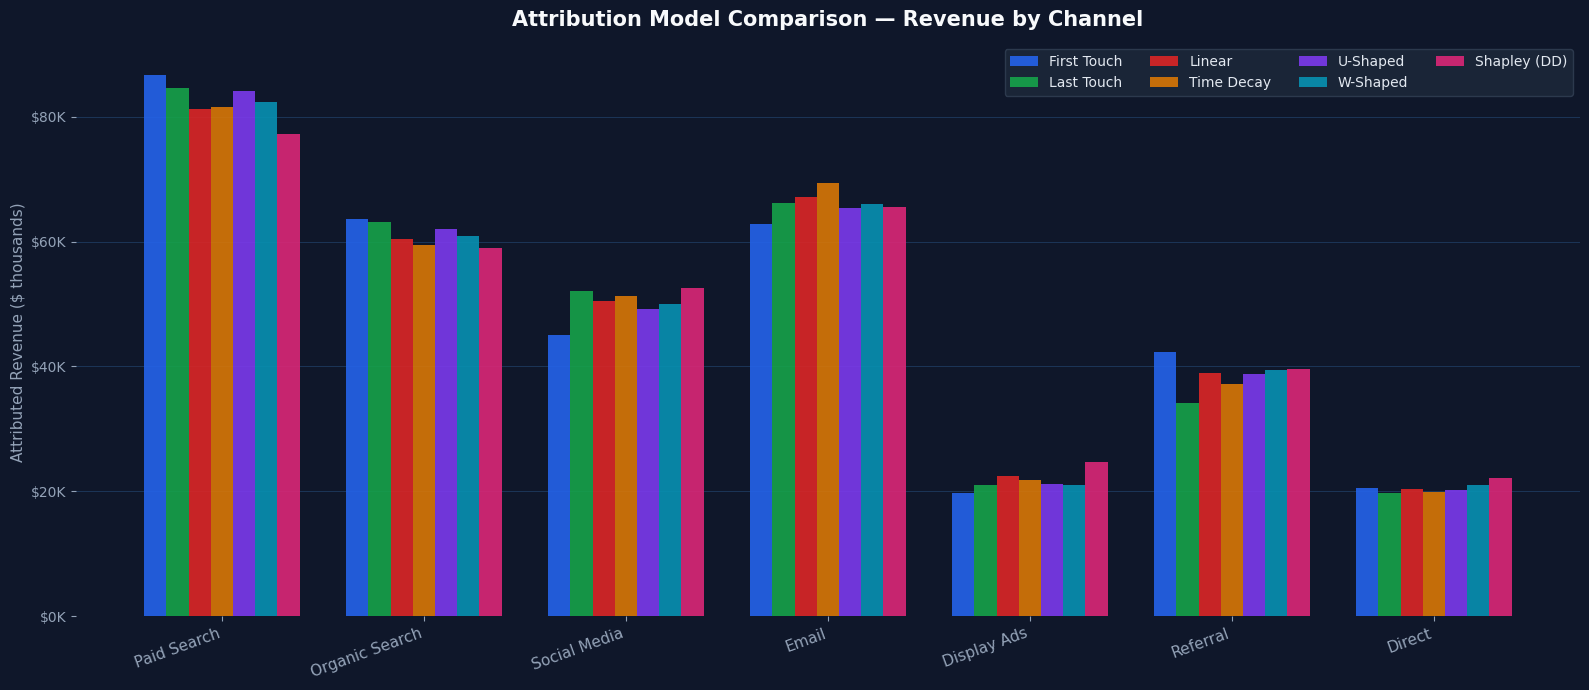

  💾  Saved → ./02_share_heatmap.png


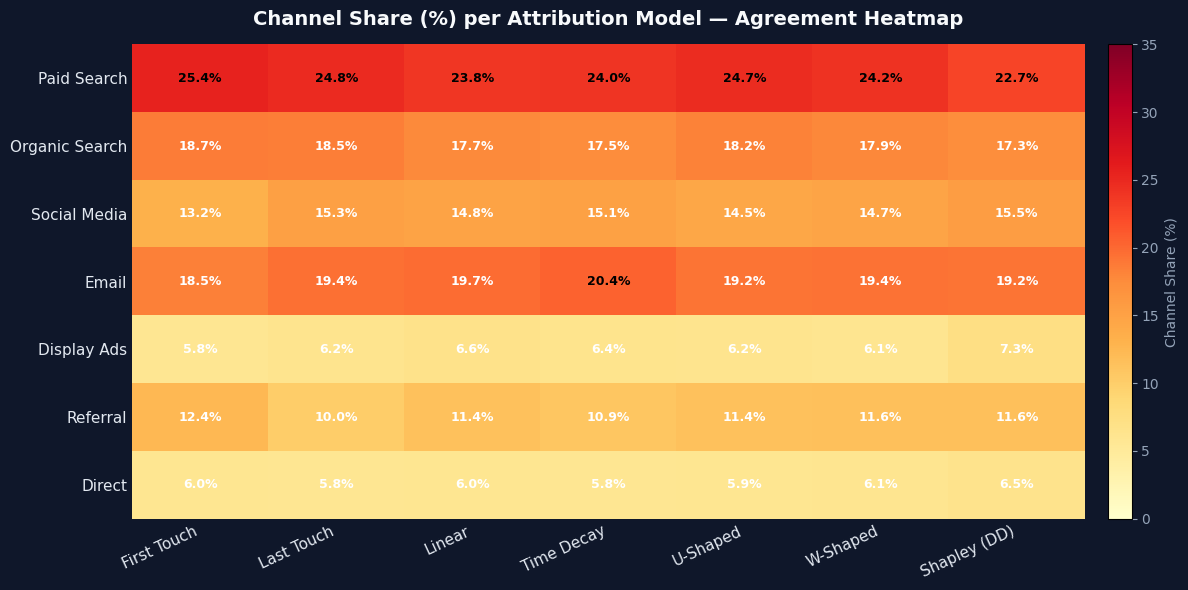

  💾  Saved → ./03_rank_bump_chart.png


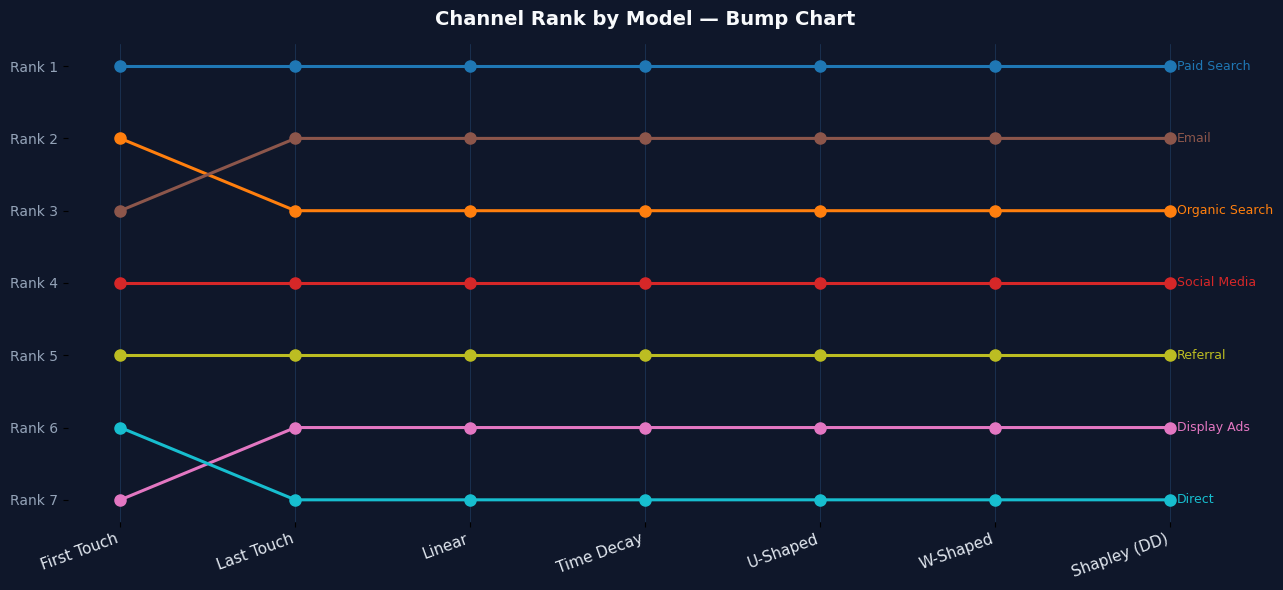

  💾  Saved → ./04_model_disagreement.png


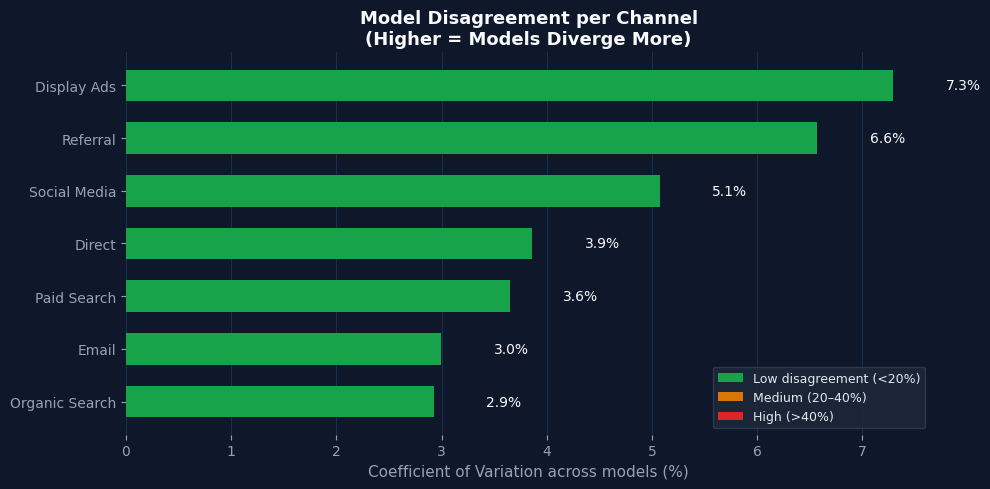


── STEP 5: Exporting CSVs ──
  💾  CSV exports saved: attribution_revenue.csv / _share.csv / _ranks.csv

✅  All done! Check the output files in your working directory.



In [ ]:
# ─────────────────────────────────────────────
#  5. SUMMARY STATS & CSV EXPORT
# ─────────────────────────────────────────────
def print_summary(result: pd.DataFrame, df_raw: pd.DataFrame):
    share = result.div(result.sum(axis=0), axis=1) * 100
    ranks = result.rank(ascending=False).astype(int)

    print("\n" + "═" * 65)
    print("  ATTRIBUTION RESULTS SUMMARY (Revenue in $)")
    print("═" * 65)
    print(result.to_string(float_format="$ {:,.0f}".format))

    print("\n" + "─" * 65)
    print("  CHANNEL SHARE PER MODEL (%)")
    print("─" * 65)
    print(share.round(1).to_string())

    print("\n" + "─" * 65)
    print("  CHANNEL RANKS PER MODEL (1 = most credit)")
    print("─" * 65)
    print(ranks.to_string())

    print("\n" + "─" * 65)
    print("  CROSS-MODEL STATISTICS PER CHANNEL")
    print("─" * 65)
    stats = pd.DataFrame({
        "Mean ($)":  result.mean(axis=1),
        "Std ($)":   result.std(axis=1),
        "CV (%)":    result.std(axis=1) / result.mean(axis=1) * 100,
        "Min ($)":   result.min(axis=1),
        "Max ($)":   result.max(axis=1),
    }).round(1)
    print(stats.to_string(float_format="${:,.0f}".format))

    print("\n" + "═" * 65)


def export_csv(result: pd.DataFrame):
    share = result.div(result.sum(axis=0), axis=1) * 100
    ranks = result.rank(ascending=False).astype(int)

    result.to_csv(os.path.join(OUTPUT_DIR, "attribution_revenue.csv"))
    share.to_csv(os.path.join(OUTPUT_DIR, "attribution_share.csv"))
    ranks.to_csv(os.path.join(OUTPUT_DIR, "attribution_ranks.csv"))
    print("  💾  CSV exports saved: attribution_revenue.csv / _share.csv / _ranks.csv")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
def main():
    print("\n" + "═" * 65)
    print("  MARKETING ATTRIBUTION MODEL COMPARISON")
    print("  Data Analytics Project")
    print("═" * 65 + "\n")

    # 1. Generate data
    print("── STEP 1: Generating sample data ──")
    df = generate_journeys(N_JOURNEYS)

    # 2. Run models
    print("── STEP 2: Running attribution models ──")
    result = run_all_models(df)
    print("  ✅  All 7 models computed.\n")

    # 3. Summary
    print("── STEP 3: Summary statistics ──")
    print_summary(result, df)

    # 4. Charts
    print("\n── STEP 4: Generating visualizations ──")
    plot_attribution_comparison(result)
    plot_share_heatmap(result)
    plot_rank_comparison(result)
    plot_model_variance(result)

    # 5. Export
    print("\n── STEP 5: Exporting CSVs ──")
    export_csv(result)

    print("\n✅  All done! Check the output files in your working directory.\n")


if __name__ == "__main__":
    main()